# ROI File Visualization

Visualize ImageJ/Fiji ROI files using `read-roi`.

**Supported inputs:**
- Single `.roi` file
- `RoiSet.zip` (multiple ROIs)
- Optional background image (PNG/TIF)

In [47]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon, Rectangle, Ellipse
from matplotlib.collections import PatchCollection
import matplotlib.cm as cm
from PIL import Image
import read_roi

## Configuration

In [48]:
# --- Set paths here ---
ROI_PATH = Path("/home/pony/projects/ienf_q/nas/data_0320/S222-2_a/S222-2_a.zip")  # or "path/to/single.roi"

IMAGE_PATH = Path("/home/pony/projects/ienf_q/nas/data_0320/S222-2_a/S222-2_a.tif")  # Optional: Path("path/to/image.png") or None

# Display options
FIGSIZE = (12, 8)
ROI_ALPHA = 0.4       # Fill transparency|
ROI_LINE_WIDTH = 1.5
SHOW_LABELS = True    # Show ROI name labels

## Load ROI File

In [49]:
def load_rois(roi_path: Path) -> dict:
    roi_path = Path(roi_path)
    if roi_path.suffix.lower() == ".zip":
        rois = read_roi.read_roi_zip(str(roi_path))
    elif roi_path.suffix.lower() == ".roi":
        rois = read_roi.read_roi_file(str(roi_path))
    else:
        raise ValueError(f"Unsupported file type: {roi_path.suffix}")
    return rois


rois = load_rois(ROI_PATH)
print(f"Loaded {len(rois)} ROI(s) from: {ROI_PATH.name}")
print()

# Summary table
print(f"{'Name':<30} {'Type':<15} {'Position':>15}")
print("-" * 62)
for name, roi in rois.items():
    roi_type = roi.get("type", "unknown")
    x = roi.get("left", roi.get("x", roi.get("x1", "?")))
    y = roi.get("top", roi.get("y", roi.get("y1", "?")))
    print(f"{name:<30} {roi_type:<15} ({x}, {y})")

Loaded 457 ROI(s) from: S222-2_a.zip

Name                           Type                   Position
--------------------------------------------------------------
0001-0170                      traced          ([1726, 1724, 1724, 1726], [171, 171, 170, 170])
0002-0183                      traced          ([1631, 1625, 1625, 1631], [184, 184, 183, 183])
0003-0187                      traced          ([1641, 1639, 1639, 1641], [188, 188, 186, 186])
0004-0191                      traced          ([1801, 1799, 1799, 1800, 1800, 1801], [194, 194, 191, 191, 189, 189])
0005-0192                      traced          ([1640, 1639, 1639, 1638, 1638, 1639, 1639, 1640], [193, 193, 194, 194, 191, 191, 190, 190])
0006-0191                      traced          ([1670, 1669, 1669, 1665, 1665, 1668, 1668, 1669, 1669, 1670], [192, 192, 193, 193, 192, 192, 191, 191, 190, 190])
0007-0191                      traced          ([1648, 1647, 1647, 1648], [192, 192, 191, 191])
0008-0192                      t

## Inspect a Single ROI

In [50]:
# Show raw data for the first ROI
first_name = next(iter(rois))
first_roi = rois[first_name]
print(f"ROI name: {first_name}")
for k, v in first_roi.items():
    if isinstance(v, (list, np.ndarray)) and len(v) > 10:
        print(f"  {k}: [{v[0]}, {v[1]}, ... ] (length={len(v)})")
    else:
        print(f"  {k}: {v}")

ROI name: 0001-0170
  type: traced
  x: [1726, 1724, 1724, 1726]
  y: [171, 171, 170, 170]
  n: 4
  width: 0
  name: 0001-0170
  position: 0


## Visualization Helpers

In [51]:
def roi_to_patch(roi: dict, color, alpha=0.4, lw=1.5):
    """Convert a read-roi dict to a matplotlib patch (or list of xy coords)."""
    roi_type = roi.get("type", "").lower()

    if roi_type in ("polygon", "freehand", "traced", "freeline"):
        xs = np.array(roi["x"])
        ys = np.array(roi["y"])
        xy = np.column_stack([xs, ys])
        patch = Polygon(xy, closed=True, facecolor=color, edgecolor=color,
                        alpha=alpha, linewidth=lw)
        centroid = (xs.mean(), ys.mean())
        return patch, centroid

    elif roi_type == "rectangle":
        x = roi["left"]
        y = roi["top"]
        w = roi["width"]
        h = roi["height"]
        patch = Rectangle((x, y), w, h, facecolor=color, edgecolor=color,
                           alpha=alpha, linewidth=lw)
        centroid = (x + w / 2, y + h / 2)
        return patch, centroid

    elif roi_type == "oval":
        x = roi["left"]
        y = roi["top"]
        w = roi["width"]
        h = roi["height"]
        patch = Ellipse((x + w / 2, y + h / 2), w, h,
                        facecolor=color, edgecolor=color,
                        alpha=alpha, linewidth=lw)
        centroid = (x + w / 2, y + h / 2)
        return patch, centroid

    elif roi_type in ("line", "polyline"):
        xs = np.array(roi.get("x", [roi.get("x1", 0), roi.get("x2", 0)]))
        ys = np.array(roi.get("y", [roi.get("y1", 0), roi.get("y2", 0)]))
        xy = np.column_stack([xs, ys])
        # Lines have no fill — return None patch and draw separately
        return None, (xs.mean(), ys.mean()), xy

    else:
        # Fallback: try x/y arrays
        if "x" in roi and "y" in roi:
            xs = np.array(roi["x"])
            ys = np.array(roi["y"])
            xy = np.column_stack([xs, ys])
            patch = Polygon(xy, closed=True, facecolor=color, edgecolor=color,
                            alpha=alpha, linewidth=lw)
            return patch, (xs.mean(), ys.mean())
        return None, (0, 0)

## Plot All ROIs

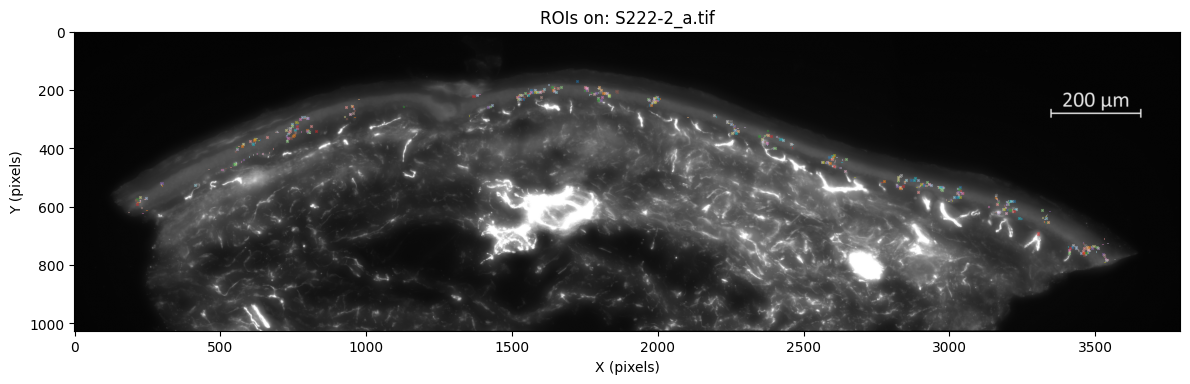

In [52]:
fig, ax = plt.subplots(figsize=FIGSIZE)

# Background image
if IMAGE_PATH is not None:
    img = np.array(Image.open(IMAGE_PATH))
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(f"ROIs on: {Path(IMAGE_PATH).name}")
else:
    ax.set_facecolor("#1a1a1a")
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"ROIs from: {ROI_PATH.name}  (n={len(rois)})")

colors = cm.tab20(np.linspace(0, 1, 20))  # fixed 20-color cycle
show_labels = SHOW_LABELS and len(rois) <= 80  # skip labels when too many ROIs
show_legend = len(rois) <= 30

legend_handles = []

for i, (name, roi) in enumerate(rois.items()):
    color = colors[i % len(colors)]
    roi_type = roi.get("type", "").lower()

    result = roi_to_patch(roi, color=color, alpha=ROI_ALPHA, lw=ROI_LINE_WIDTH)

    if len(result) == 3:
        _, centroid, xy = result
        ax.plot(xy[:, 0], xy[:, 1], color=color, linewidth=ROI_LINE_WIDTH * 2)
    elif result[0] is not None:
        patch, centroid = result
        ax.add_patch(patch)
    else:
        continue

    if show_labels:
        ax.text(centroid[0], centroid[1], name, fontsize=6,
                ha="center", va="center", color="white",
                bbox=dict(boxstyle="round,pad=0.15", fc=color, alpha=0.7, lw=0))

    if show_legend:
        legend_handles.append(
            mpatches.Patch(facecolor=color, edgecolor=color, alpha=0.8,
                           label=f"{name} ({roi_type})")
        )

if legend_handles:
    ax.legend(handles=legend_handles, loc="upper right",
              fontsize=7, framealpha=0.8,
              bbox_to_anchor=(1.18, 1))

ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.tight_layout()
plt.show()
plt.close(fig)

## Per-ROI Detail View

In [ ]:
# MAX_PER_PAGE = 40  # limit ROIs per figure to avoid MemoryError
# CELL_SIZE = 2.5    # inches per subplot

# items = list(rois.items())
# bg_img = np.array(Image.open(IMAGE_PATH)) if IMAGE_PATH else None

# for page_start in range(0, len(items), MAX_PER_PAGE):
#     page_items = items[page_start : page_start + MAX_PER_PAGE]
#     n = len(page_items)
#     cols = min(5, n)
#     rows = (n + cols - 1) // cols

#     fig, axes = plt.subplots(rows, cols, figsize=(cols * CELL_SIZE, rows * CELL_SIZE))
#     axes_flat = np.array(axes).flatten() if n > 1 else [axes]

#     for i, (name, roi) in enumerate(page_items):
#         ax = axes_flat[i]
#         color = colors[(page_start + i) % len(colors)]
#         roi_type = roi.get("type", "").lower()

#         x = roi.get("left", roi.get("x", [0]))
#         y = roi.get("top", roi.get("y", [0]))
#         w = roi.get("width", 50)
#         h = roi.get("height", 50)

#         if isinstance(x, (list, np.ndarray)):
#             x0, x1 = int(min(x)), int(max(x))
#             y0, y1 = int(min(y)), int(max(y))
#         else:
#             x0, x1 = int(x), int(x + w)
#             y0, y1 = int(y), int(y + h)

#         pad = 20
#         x0p, y0p = max(0, x0 - pad), max(0, y0 - pad)
#         x1p, y1p = x1 + pad, y1 + pad

#         if bg_img is not None:
#             crop = bg_img[y0p:y1p, x0p:x1p]
#             ax.imshow(crop, cmap="gray" if bg_img.ndim == 2 else None,
#                       extent=[x0p, x1p, y1p, y0p])
#         else:
#             ax.set_facecolor("#1a1a1a")
#             ax.invert_yaxis()

#         result = roi_to_patch(roi, color=color, alpha=0.5, lw=2)
#         if len(result) == 3:
#             _, _, xy = result
#             ax.plot(xy[:, 0], xy[:, 1], color=color, linewidth=2)
#         elif result[0] is not None:
#             ax.add_patch(result[0])

#         ax.set_xlim(x0p, x1p)
#         ax.set_ylim(y1p, y0p)
#         ax.set_title(f"{name}\n({roi_type})", fontsize=7)
#         ax.axis("off")

#     for j in range(n, len(axes_flat)):
#         axes_flat[j].set_visible(False)

#     page_end = min(page_start + MAX_PER_PAGE, len(items))
#     plt.suptitle(f"Per-ROI Detail  [{page_start+1}–{page_end} / {len(items)}]",
#                  fontsize=11, y=1.01)
#     # plt.tight_layout()
#     # plt.show()
#     # plt.close(fig)

## ROI Statistics

## Export Overlay Image

In [56]:
import cv2

OUTPUT_PATH = Path("roi_overlay.png")
FILL_ALPHA = 0.35   # ROI fill transparency (0=invisible, 1=opaque)
BORDER_THICKNESS = 1

# Load or create base image (BGR)
if IMAGE_PATH is not None:
    base = cv2.imread(str(IMAGE_PATH))
    if base is None:
        base = np.array(Image.open(IMAGE_PATH))
        if base.ndim == 2:
            base = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
        elif base.shape[2] == 4:
            base = cv2.cvtColor(base, cv2.COLOR_RGBA2BGR)
        else:
            base = cv2.cvtColor(base, cv2.COLOR_RGB2BGR)
else:
    # Infer canvas size from ROI bounding boxes
    all_x, all_y = [], []
    for roi in rois.values():
        if "x" in roi:
            all_x.extend(roi["x"]); all_y.extend(roi["y"])
        else:
            l, t = roi.get("left", 0), roi.get("top", 0)
            all_x += [l, l + roi.get("width", 0)]
            all_y += [t, t + roi.get("height", 0)]
    H = int(max(all_y)) + 10 if all_y else 512
    W = int(max(all_x)) + 10 if all_x else 512
    base = np.zeros((H, W, 3), dtype=np.uint8)

overlay = base.copy()

# tab20 colors → BGR uint8
cmap = plt.cm.get_cmap("tab20", 20)
COLORS_BGR = [
    (int(b * 255), int(g * 255), int(r * 255))
    for r, g, b, _ in [cmap(i) for i in range(20)]
]

for i, (name, roi) in enumerate(rois.items()):
    # color = COLORS_BGR[i % len(COLORS_BGR)]
    color = (0, 255, 255)  # cyan for better visibility
    roi_type = roi.get("type", "").lower()

    if roi_type in ("polygon", "freehand", "traced", "freeline", "polyline") or ("x" in roi and "y" in roi):
        pts = np.column_stack([roi["x"], roi["y"]]).astype(np.int32)
        cv2.fillPoly(overlay, [pts], color)
        cv2.polylines(overlay, [pts], isClosed=True, color=color, thickness=BORDER_THICKNESS)

    elif roi_type == "rectangle":
        x1, y1 = int(roi["left"]), int(roi["top"])
        x2, y2 = x1 + int(roi["width"]), y1 + int(roi["height"])
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, BORDER_THICKNESS)

    elif roi_type == "oval":
        cx = int(roi["left"] + roi["width"] / 2)
        cy = int(roi["top"] + roi["height"] / 2)
        axes_len = (int(roi["width"] / 2), int(roi["height"] / 2))
        cv2.ellipse(overlay, (cx, cy), axes_len, 0, 0, 360, color, -1)
        cv2.ellipse(overlay, (cx, cy), axes_len, 0, 0, 360, color, BORDER_THICKNESS)

    elif roi_type == "line":
        x1 = int(roi.get("x1", roi.get("x", [0])[0]))
        y1 = int(roi.get("y1", roi.get("y", [0])[0]))
        x2 = int(roi.get("x2", roi.get("x", [0, 0])[1]))
        y2 = int(roi.get("y2", roi.get("y", [0, 0])[1]))
        cv2.line(overlay, (x1, y1), (x2, y2), color, BORDER_THICKNESS * 2)

result = cv2.addWeighted(overlay, FILL_ALPHA, base, 1 - FILL_ALPHA, 0)
cv2.imwrite(str(OUTPUT_PATH), result)
print(f"Saved: {OUTPUT_PATH.resolve()}")

Saved: /home/pony/projects/ienf_q/notebooks/others/roi_overlay.png


/tmp/ipykernel_604579/2526520413.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", 20)


In [55]:
import pandas as pd

rows_data = []
for name, roi in rois.items():
    roi_type = roi.get("type", "unknown")
    row = {"name": name, "type": roi_type}

    if "x" in roi and "y" in roi:
        xs, ys = np.array(roi["x"]), np.array(roi["y"])
        row["n_points"] = len(xs)
        row["x_min"], row["x_max"] = int(xs.min()), int(xs.max())
        row["y_min"], row["y_max"] = int(ys.min()), int(ys.max())
        row["width"] = row["x_max"] - row["x_min"]
        row["height"] = row["y_max"] - row["y_min"]
        row["area_bbox"] = row["width"] * row["height"]
    elif "width" in roi:
        row["n_points"] = 4
        row["x_min"] = roi.get("left", 0)
        row["y_min"] = roi.get("top", 0)
        row["width"] = roi["width"]
        row["height"] = roi["height"]
        row["x_max"] = row["x_min"] + row["width"]
        row["y_max"] = row["y_min"] + row["height"]
        row["area_bbox"] = row["width"] * row["height"]

    rows_data.append(row)

df = pd.DataFrame(rows_data)
print(df.to_string(index=False))

     name   type  n_points  x_min  x_max  y_min  y_max  width  height  area_bbox
0001-0170 traced         4   1724   1726    170    171      2       1          2
0002-0183 traced         4   1625   1631    183    184      6       1          6
0003-0187 traced         4   1639   1641    186    188      2       2          4
0004-0191 traced         6   1799   1801    189    194      2       5         10
0005-0192 traced         8   1638   1640    190    194      2       4          8
0006-0191 traced        10   1665   1670    190    193      5       3         15
0007-0191 traced         4   1647   1648    191    192      1       1          1
0008-0192 traced         6   1751   1753    191    194      2       3          6
0009-0193 traced         4   1644   1645    192    194      1       2          2
0010-0194 traced         4   1794   1795    193    195      1       2          2
0011-0195 traced         6   1655   1658    194    196      3       2          6
0012-0195 traced         4  